# Telecom Experiment — Statistical Analysis

Paired non-parametric comparison of 6 drone deployment methods on 24 real-world
Telecom Italia snapshots (4 weeks × weekday/weekend × 3 hours).

**Design**: Randomised complete block with 30 seeds per condition.  
**Tests**: Friedman → Wilcoxon signed-rank (Holm correction) → Cliff's delta.

In [16]:
import glob
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                      'axes.grid': True, 'grid.alpha': 0.3})

# ── Config ────────────────────────────────────────────────────────
RESULTS_DIR = Path('../results/telecom_v2')
ALPHA = 0.05           # significance level

_ALL_METHODS = ['kmeans', 'analytic', 'analytic_pca',
                'repulsive_lloyd', 'altitude_stagger', 'greedy']
METHOD_LABELS = {
    'kmeans':          'K-Means',
    'analytic':        'Analytic',
    'analytic_pca':    'Analytic PCA',
    'repulsive_lloyd': 'Rep. Lloyd',
    'altitude_stagger':'Alt. Stagger',
    'greedy':          'Greedy',
}
COLORS = {
    'kmeans': '#0072B2', 'analytic': '#E69F00', 'analytic_pca': '#F0E442',
    'repulsive_lloyd': '#009E73', 'altitude_stagger': '#D55E00', 'greedy': '#CC79A7',
}
MARKERS = {
    'kmeans': 'o', 'analytic': 's', 'analytic_pca': '^',
    'repulsive_lloyd': 'P', 'altitude_stagger': 'X', 'greedy': 'D',
}

print(f'Results directory: {RESULTS_DIR.resolve()}')

Results directory: /Users/jbn/Documents/KAUST/dronecomm/results/telecom_v2


## 1. Load & merge results

In [17]:
# Load main-phase CSV files
csv_files = sorted(glob.glob(str(RESULTS_DIR / 'main' / 'task_*.csv')))
print(f'Found {len(csv_files)} task files')

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
METHODS = [m for m in _ALL_METHODS if m in df['method'].unique()]
n_snap = df['snapshot_idx'].nunique()
n_seeds = df['seed'].nunique()

print(f'Rows: {len(df):,}')
print(f'Snapshots: {n_snap},  Seeds: {n_seeds}')
print(f'Drone counts: {sorted(df["n_drones"].unique())}')
print(f'User counts:  {sorted(df["n_users"].unique())}')
print(f'Methods: {METHODS}')
df.head()

Found 432 task files
Rows: 77,760
Snapshots: 24,  Seeds: 30
Drone counts: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)]
User counts:  [np.int64(200), np.int64(400), np.int64(800)]
Methods: ['kmeans', 'analytic', 'analytic_pca', 'repulsive_lloyd', 'altitude_stagger', 'greedy']


,snapshot_idx,snapshot_date,snapshot_hour,day_type,n_drones,n_users,method,seed,coverage_pct,throughput_mbps,mean_sinr_db,median_sinr_db,min_sinr_db,sinr_5th_pct_db,total_interference_dbm,worst_pair_interference_dbm,build_time_s
0,0,2013-11-04,10,weekday,5,200,kmeans,1000,89.0,13528.047927,19.871023,19.118577,-2.515534,0.498354,-63.394678,-65.932728,0.0020
1,0,2013-11-04,10,weekday,5,200,analytic,1000,87.0,10094.572877,14.336339,15.230431,-10.664383,-3.882103,-65.698959,-67.696629,0.0021
2,0,2013-11-04,10,weekday,5,200,analytic_pca,1000,82.5,9995.135012,13.700528,15.302383,-15.816781,-7.989308,-65.698959,-67.696629,0.0179
3,0,2013-11-04,10,weekday,5,200,repulsive_lloyd,1000,86.5,10082.493328,14.244832,15.359848,-10.799732,-4.483838,-65.973545,-67.897052,0.0033
4,0,2013-11-04,10,weekday,5,200,altitude_stagger,1000,87.0,10094.572877,14.336339,15.230431,-10.664383,-3.882103,-65.698959,-67.696629,0.0033


## 2. Summary statistics

In [18]:
# Mean ± std for each method × n_drones (averaged over snapshots, seeds, user counts)
metrics_of_interest = ['coverage_pct', 'throughput_mbps', 'mean_sinr_db',
                       'sinr_5th_pct_db', 'total_interference_dbm']

summary = (df.groupby(['n_drones', 'method'])[metrics_of_interest]
           .agg(['mean', 'std'])
           .round(2))

# Show for representative case
for nd in [10, 20, 30]:
    print(f'\n=== N = {nd} drones ===')
    sub = summary.loc[nd].reindex(METHODS)
    display(sub)


=== N = 10 drones ===


coverage_pct       throughput_mbps           mean_sinr_db  \
                         mean   std            mean       std         mean   
method                                                                       
kmeans                  89.36  2.44        25596.85  13542.90        16.08   
analytic                82.06  3.50        18780.13   9622.96        11.20   
analytic_pca            67.16  4.64        14757.63   7809.84         7.14   
repulsive_lloyd         82.99  3.31        19101.15   9825.21        11.43   
altitude_stagger        82.04  3.55        18778.21   9622.20        11.19   
greedy                  93.88  2.04        19466.11  10154.96        12.07   

                       sinr_5th_pct_db       total_interference_dbm        
                   std            mean   std                   mean   std  
method                                                                     
kmeans            1.32            1.19  0.66                 -44.22  6.56  
analytic          1.20           -3.71  2.27                 -47.64  6.57  
analytic_pca      1.43          -11.11  2.49                 -47.64  6.57  
repulsive_lloyd   1.14           -3.36  2.31                 -47.36  6.51  
altitude_stagger  1.21           -3.74  2.35                 -47.65  6.57  
greedy            1.55            1.94  2.21                 -38.70  9.89


=== N = 20 drones ===


coverage_pct       throughput_mbps           mean_sinr_db  \
                         mean   std            mean       std         mean   
method                                                                       
kmeans                  82.46  4.60        19107.76  10112.11        11.57   
analytic                80.83  3.80        18049.93   8637.57        10.66   
analytic_pca            63.48  4.01        13471.20   6674.81         5.84   
repulsive_lloyd         81.80  3.51        18466.00   9004.88        10.94   
altitude_stagger        81.17  3.69        18050.30   8665.98        10.72   
greedy                  88.54  2.83        16458.88   8913.38         9.55   

                       sinr_5th_pct_db       total_interference_dbm        
                   std            mean   std                   mean   std  
method                                                                     
kmeans            1.07            0.36  0.60                 -35.98  4.08  
analytic          1.36           -6.48  2.85                 -41.00  4.65  
analytic_pca      1.29          -13.93  2.18                 -41.00  4.65  
repulsive_lloyd   1.27           -6.11  2.91                 -40.97  4.59  
altitude_stagger  1.33           -5.68  2.80                 -40.63  4.73  
greedy            1.41           -2.89  2.78                 -26.64  8.97


=== N = 30 drones ===


coverage_pct       throughput_mbps          mean_sinr_db  \
                         mean   std            mean      std         mean   
method                                                                      
kmeans                  69.78  6.98        15523.50  8204.30         8.84   
analytic                82.57  3.84        18806.18  8746.23        11.25   
analytic_pca            63.92  3.93        13609.53  6574.08         6.00   
repulsive_lloyd         83.32  3.47        19172.05  9083.52        11.48   
altitude_stagger        82.76  3.65        18687.90  8837.46        11.24   
greedy                  84.94  3.60        15429.60  8240.92         8.52   

                       sinr_5th_pct_db       total_interference_dbm        
                   std            mean   std                   mean   std  
method                                                                     
kmeans            0.90           -0.88  0.79                 -30.50  3.18  
analytic          1.54           -7.38  3.42                 -34.71  3.94  
analytic_pca      1.34          -14.05  2.18                 -34.71  3.94  
repulsive_lloyd   1.44           -7.08  3.54                 -34.67  3.91  
altitude_stagger  1.47           -5.63  3.52                 -34.49  3.69  
greedy            1.31           -5.64  3.52                 -21.88  6.74

## 3. Coverage vs drone count (with 95% CIs)

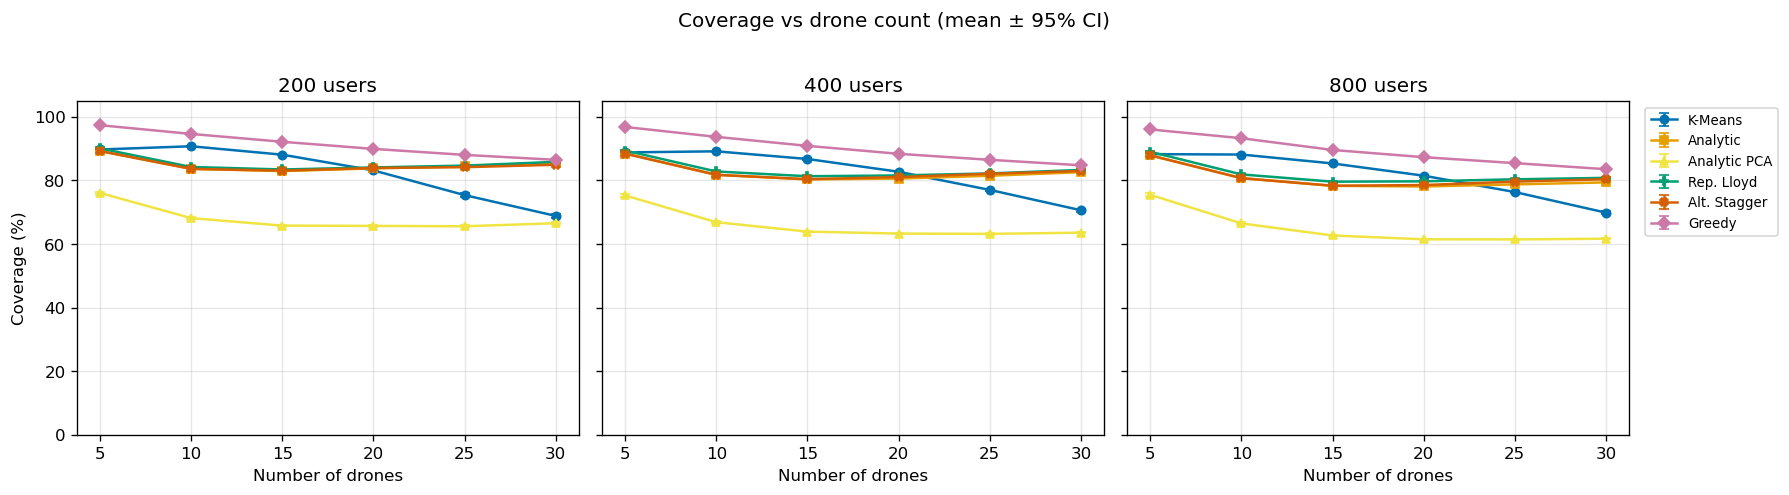

In [19]:
user_counts = sorted(df['n_users'].unique())
fig, axes = plt.subplots(1, len(user_counts), figsize=(5 * len(user_counts), 4),
                         sharey=True)
if len(user_counts) == 1:
    axes = [axes]

for ax, nu in zip(axes, user_counts):
    sub = df[df['n_users'] == nu]
    for m in METHODS:
        ms = sub[sub['method'] == m]
        agg = ms.groupby('n_drones')['coverage_pct'].agg(['mean', 'std', 'count'])
        ci95 = 1.96 * agg['std'] / np.sqrt(agg['count'])
        ax.errorbar(agg.index, agg['mean'], yerr=ci95,
                    label=METHOD_LABELS.get(m, m),
                    color=COLORS.get(m), marker=MARKERS.get(m),
                    markersize=5, capsize=3, linewidth=1.5)
    ax.set_xlabel('Number of drones')
    ax.set_title(f'{nu} users')
    ax.set_ylim(0, 105)

axes[0].set_ylabel('Coverage (%)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('Coverage vs drone count (mean ± 95% CI)', y=1.02)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'coverage_vs_drones.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 4. Throughput & interference vs drone count

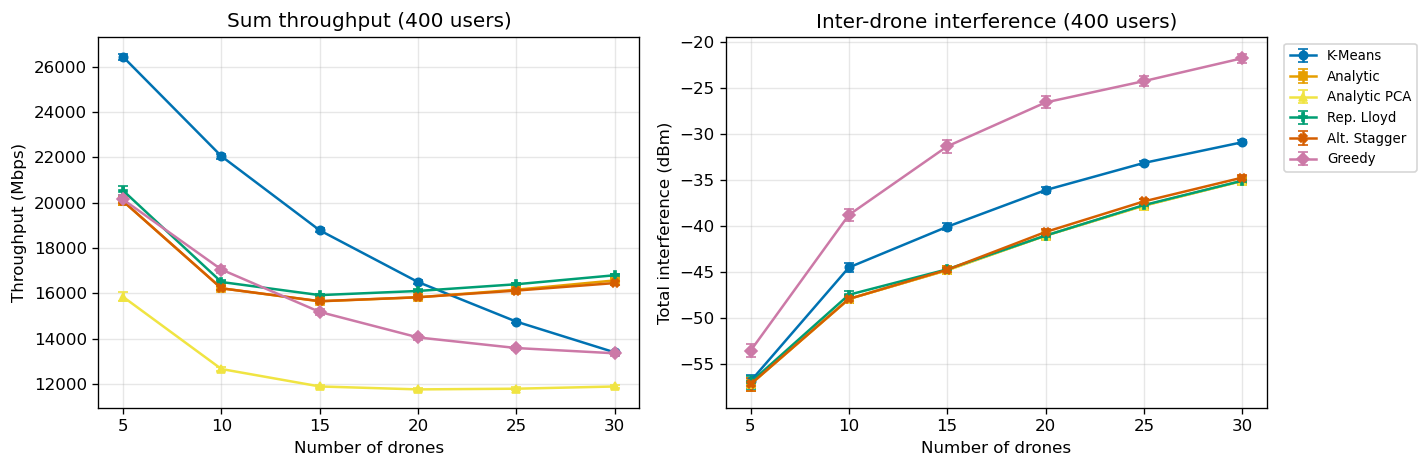

In [20]:
nu_ref = 400 if 400 in df['n_users'].unique() else df['n_users'].median()
sub = df[df['n_users'] == nu_ref]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for m in METHODS:
    ms = sub[sub['method'] == m]
    kw = dict(label=METHOD_LABELS.get(m, m), color=COLORS.get(m),
              marker=MARKERS.get(m), markersize=5, linewidth=1.5)
    # Throughput
    agg = ms.groupby('n_drones')['throughput_mbps'].agg(['mean', 'std', 'count'])
    ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
    ax1.errorbar(agg.index, agg['mean'], yerr=ci, capsize=3, **kw)
    # Interference
    agg = ms.groupby('n_drones')['total_interference_dbm'].agg(['mean', 'std', 'count'])
    ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
    ax2.errorbar(agg.index, agg['mean'], yerr=ci, capsize=3, **kw)

ax1.set_xlabel('Number of drones'); ax1.set_ylabel('Throughput (Mbps)')
ax1.set_title(f'Sum throughput ({int(nu_ref)} users)')
ax2.set_xlabel('Number of drones'); ax2.set_ylabel('Total interference (dBm)')
ax2.set_title(f'Inter-drone interference ({int(nu_ref)} users)')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'throughput_interference.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 5. Violin plots — distribution of coverage across snapshots & seeds

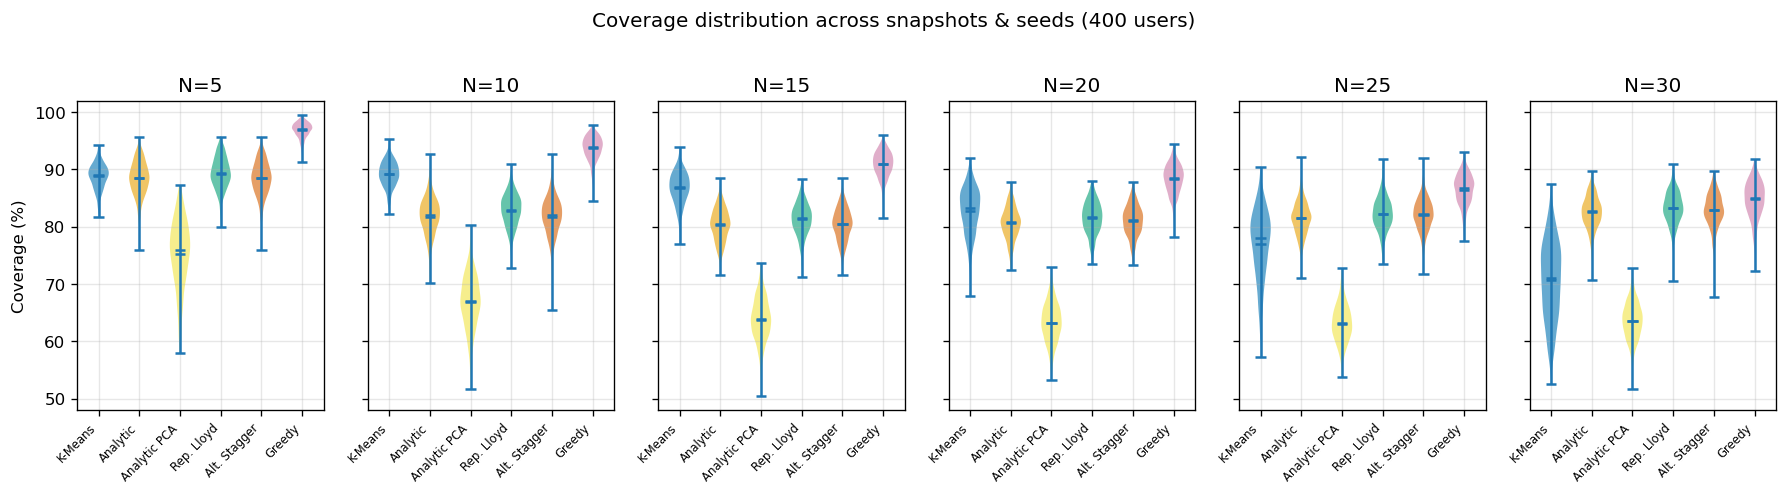

In [21]:
drone_counts_plot = sorted(df['n_drones'].unique())
n_dc = len(drone_counts_plot)
fig, axes = plt.subplots(1, n_dc, figsize=(2.5 * n_dc, 4), sharey=True)
if n_dc == 1:
    axes = [axes]

sub = df[df['n_users'] == nu_ref]
for ax, nd in zip(axes, drone_counts_plot):
    data = [sub[(sub['n_drones'] == nd) & (sub['method'] == m)]['coverage_pct'].values
            for m in METHODS]
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS.get(METHODS[i], 'gray'))
        pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(METHODS) + 1))
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in METHODS],
                        rotation=45, ha='right', fontsize=7)
    ax.set_title(f'N={nd}')

axes[0].set_ylabel('Coverage (%)')
fig.suptitle(f'Coverage distribution across snapshots & seeds ({int(nu_ref)} users)',
             y=1.02)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'coverage_violins.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 6. Friedman test — omnibus comparison across methods

For each `(n_drones, n_users)` cell, we treat each `(snapshot, seed)` pair as a block
and test $H_0$: all methods have equal median coverage.

In [22]:
metric = 'coverage_pct'

friedman_results = []
for (nd, nu), grp in df.groupby(['n_drones', 'n_users']):
    # Pivot: rows = (snapshot, seed), columns = method
    piv = grp.pivot_table(index=['snapshot_idx', 'seed'],
                          columns='method', values=metric)
    piv = piv.reindex(columns=METHODS).dropna()
    if piv.shape[0] < 10:
        continue
    samples = [piv[m].values for m in METHODS]
    stat, p = stats.friedmanchisquare(*samples)
    friedman_results.append({
        'n_drones': nd, 'n_users': nu,
        'chi2': round(stat, 2), 'p_value': p,
        'n_blocks': piv.shape[0],
        'significant': p < ALPHA,
    })

df_friedman = pd.DataFrame(friedman_results)
print(f'Friedman test results (alpha={ALPHA}):\n')
display(df_friedman.style.format({'p_value': '{:.2e}', 'chi2': '{:.1f}'}))

Friedman test results (alpha=0.05):



,n_drones,n_users,chi2,p_value,n_blocks,significant
0,5,200,2819.6,0.00e+00,720,True
1,5,400,2793.2,0.00e+00,720,True
2,5,800,2766.2,0.00e+00,720,True
3,10,200,3370.6,0.00e+00,720,True
4,10,400,3324.6,0.00e+00,720,True
5,10,800,3325.8,0.00e+00,720,True
6,15,200,3074.9,0.00e+00,720,True
7,15,400,3258.8,0.00e+00,720,True
8,15,800,3309.2,0.00e+00,720,True
9,20,200,2238.3,0.00e+00,720,True


## 7. Post-hoc pairwise Wilcoxon signed-rank tests (Holm correction)

In [23]:
def holm_bonferroni(p_values):
    """Holm-Bonferroni step-down correction. Returns adjusted p-values."""
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.zeros(n)
    for rank, idx in enumerate(order):
        adjusted[idx] = p_values[idx] * (n - rank)
    # Enforce monotonicity
    cummax = 0.0
    for idx in order:
        cummax = max(cummax, adjusted[idx])
        adjusted[idx] = min(cummax, 1.0)
    return adjusted


def cliffs_delta(x, y):
    """Cliff's delta effect size (non-parametric).
    |d| < 0.147 negligible, < 0.33 small, < 0.474 medium, else large."""
    n1, n2 = len(x), len(y)
    more = np.sum(x[:, None] > y[None, :])
    less = np.sum(x[:, None] < y[None, :])
    return (more - less) / (n1 * n2)


# Run pairwise tests for a representative condition
nd_test, nu_test = 15, 400
if nu_test not in df['n_users'].unique():
    nu_test = df['n_users'].unique()[0]

grp = df[(df['n_drones'] == nd_test) & (df['n_users'] == nu_test)]
piv = (grp.pivot_table(index=['snapshot_idx', 'seed'],
                       columns='method', values=metric)
       .reindex(columns=METHODS).dropna())

pairs = list(combinations(METHODS, 2))
raw_p = []
test_rows = []
for m1, m2 in pairs:
    x, y = piv[m1].values, piv[m2].values
    stat, p = stats.wilcoxon(x, y, alternative='two-sided')
    d = cliffs_delta(x, y)
    raw_p.append(p)
    test_rows.append({
        'method_1': METHOD_LABELS.get(m1, m1),
        'method_2': METHOD_LABELS.get(m2, m2),
        'mean_diff': round(np.mean(x - y), 2),
        'cliffs_d': round(d, 3),
        'p_raw': p,
    })

adjusted = holm_bonferroni(np.array(raw_p))
for i, row in enumerate(test_rows):
    row['p_adjusted'] = adjusted[i]
    row['significant'] = adjusted[i] < ALPHA

df_posthoc = pd.DataFrame(test_rows)
print(f'Post-hoc Wilcoxon signed-rank (N={nd_test}, users={nu_test}, '
      f'n_blocks={piv.shape[0]})\n')
display(df_posthoc.style.format({
    'p_raw': '{:.2e}', 'p_adjusted': '{:.2e}', 'cliffs_d': '{:.3f}',
}))

Post-hoc Wilcoxon signed-rank (N=15, users=400, n_blocks=720)



,method_1,method_2,mean_diff,cliffs_d,p_raw,p_adjusted,significant
0,K-Means,Analytic,6.430000,0.891,5.90e-119,4.13e-118,True
1,K-Means,Analytic PCA,22.850000,1.000,1.54e-119,2.29e-118,True
2,K-Means,Rep. Lloyd,5.430000,0.840,5.81e-117,2.90e-116,True
3,K-Means,Alt. Stagger,6.350000,0.888,7.49e-119,4.49e-118,True
4,K-Means,Greedy,-4.130000,-0.762,2.84e-97,1.14e-96,True
5,Analytic,Analytic PCA,16.420000,1.000,1.53e-119,2.29e-118,True
6,Analytic,Rep. Lloyd,-1.000000,-0.199,4.80e-39,1.44e-38,True
7,Analytic,Alt. Stagger,-0.080000,-0.016,2.43e-09,2.43e-09,True
8,Analytic,Greedy,-10.560000,-0.996,1.59e-119,2.29e-118,True
9,Analytic PCA,Rep. Lloyd,-17.420000,-1.000,1.53e-119,2.29e-118,True


## 8. Critical difference diagram

Nemenyi post-hoc test: methods connected by a bar are **not** significantly different.

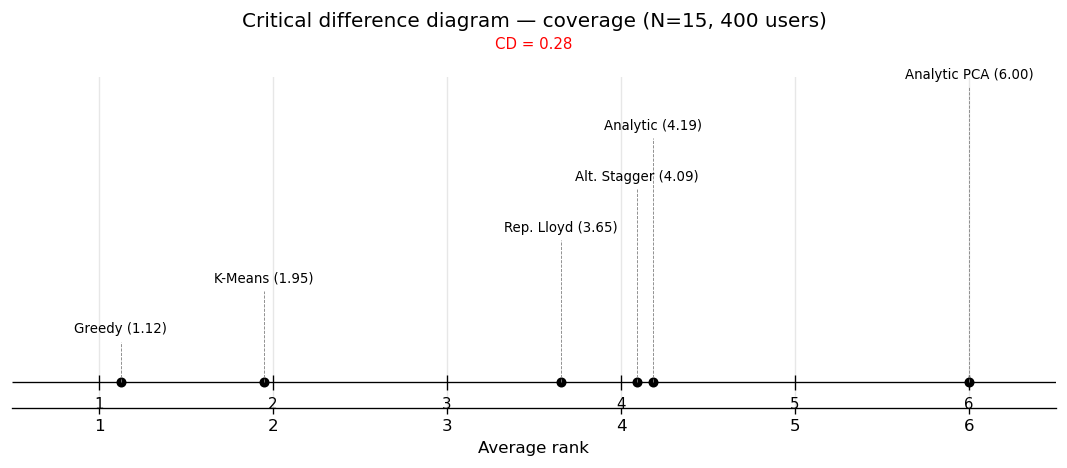

In [24]:
def critical_difference_diagram(piv, method_names, labels, alpha=0.05, ax=None):
    """Draw a critical difference diagram (Demsar 2006)."""
    k = len(method_names)
    n = piv.shape[0]

    # Compute average ranks (higher coverage = better = lower rank)
    ranks = piv[method_names].rank(axis=1, ascending=False)
    avg_ranks = ranks.mean().values

    # Nemenyi critical difference
    q_alpha = {  # q values for alpha=0.05, k groups
        2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
        7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164,
    }
    q = q_alpha.get(k, 2.850)
    cd = q * np.sqrt(k * (k + 1) / (6.0 * n))

    # Sort methods by average rank
    order = np.argsort(avg_ranks)
    sorted_names = [method_names[i] for i in order]
    sorted_ranks = avg_ranks[order]
    sorted_labels = [labels.get(m, m) for m in sorted_names]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 2.5))

    # Draw axis
    lo, hi = 0.5, k + 0.5
    ax.set_xlim(lo, hi)
    ax.set_ylim(-0.5, k)
    ax.hlines(0, lo, hi, color='black', linewidth=0.8)
    for i in range(1, k + 1):
        ax.vlines(i, -0.15, 0.15, color='black', linewidth=0.8)
        ax.text(i, -0.3, str(i), ha='center', va='top', fontsize=9)

    # Place methods
    half = k // 2
    for i, (name, rank, label) in enumerate(zip(sorted_names, sorted_ranks, sorted_labels)):
        y = i + 0.8
        side = -1 if i < half else 1
        ax.plot(rank, 0, 'ko', markersize=5)
        ax.vlines(rank, 0, y, color='gray', linewidth=0.5, linestyle='--')
        ax.text(rank, y + 0.1, f'{label} ({rank:.2f})',
                ha='center', va='bottom', fontsize=8)

    # Draw CD bar
    y_cd = k + 0.3
    mid = (lo + hi) / 2
    ax.annotate('', xy=(mid - cd / 2, y_cd), xytext=(mid + cd / 2, y_cd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax.text(mid, y_cd + 0.2, f'CD = {cd:.2f}', ha='center', va='bottom',
            fontsize=9, color='red')

    # Draw cliques (groups not significantly different)
    clique_y = -0.8
    for i in range(k):
        for j in range(i + 1, k):
            if abs(sorted_ranks[i] - sorted_ranks[j]) < cd:
                ax.hlines(clique_y, sorted_ranks[i], sorted_ranks[j],
                          color='gray', linewidth=3, alpha=0.5)
                clique_y -= 0.3

    ax.set_xlabel('Average rank')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    return ax


fig, ax = plt.subplots(figsize=(9, 4))
critical_difference_diagram(piv, METHODS, METHOD_LABELS, alpha=ALPHA, ax=ax)
ax.set_title(f'Critical difference diagram — coverage (N={nd_test}, {nu_test} users)',
             pad=30)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'critical_difference.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 9. Full pairwise significance matrix (all drone counts)

In [25]:
def significance_matrix(df, methods, nd, nu, metric='coverage_pct', alpha=0.05):
    """Return a DataFrame of adjusted p-values for all method pairs."""
    grp = df[(df['n_drones'] == nd) & (df['n_users'] == nu)]
    piv = (grp.pivot_table(index=['snapshot_idx', 'seed'],
                           columns='method', values=metric)
           .reindex(columns=methods).dropna())
    k = len(methods)
    mat = pd.DataFrame(np.nan, index=methods, columns=methods)
    raw_ps = []
    pairs_idx = []
    for i, j in combinations(range(k), 2):
        x = piv[methods[i]].values
        y = piv[methods[j]].values
        _, p = stats.wilcoxon(x, y)
        raw_ps.append(p)
        pairs_idx.append((i, j))
    adjusted = holm_bonferroni(np.array(raw_ps))
    for idx, (i, j) in enumerate(pairs_idx):
        mat.iloc[i, j] = adjusted[idx]
        mat.iloc[j, i] = adjusted[idx]
    return mat


drone_counts = sorted(df['n_drones'].unique())
print(f'Pairwise Wilcoxon p-values (Holm-adjusted), metric={metric}, '
      f'users={int(nu_test)}\n')
for nd in drone_counts:
    mat = significance_matrix(df, METHODS, nd, nu_test, metric)
    mat.index = [METHOD_LABELS.get(m, m) for m in METHODS]
    mat.columns = [METHOD_LABELS.get(m, m) for m in METHODS]
    print(f'--- N = {nd} ---')
    display(mat.style.format('{:.2e}', na_rep='—')
            .applymap(lambda v: 'background-color: #d4edda' if isinstance(v, float) and v < ALPHA
                      else '', subset=pd.IndexSlice[:, :]))
    print()

Pairwise Wilcoxon p-values (Holm-adjusted), metric=coverage_pct, users=400

--- N = 5 ---


,K-Means,Analytic,Analytic PCA,Rep. Lloyd,Alt. Stagger,Greedy
K-Means,—,1.57e-02,2.19e-118,1.97e-08,1.57e-02,2.19e-118
Analytic,1.57e-02,—,2.19e-118,5.40e-33,3.17e-01,2.19e-118
Analytic PCA,2.19e-118,2.19e-118,—,2.19e-118,2.19e-118,2.19e-118
Rep. Lloyd,1.97e-08,5.40e-33,2.19e-118,—,5.40e-33,2.19e-118
Alt. Stagger,1.57e-02,3.17e-01,2.19e-118,5.40e-33,—,2.19e-118
Greedy,2.19e-118,2.19e-118,2.19e-118,2.19e-118,2.19e-118,—



--- N = 10 ---


,K-Means,Analytic,Analytic PCA,Rep. Lloyd,Alt. Stagger,Greedy
K-Means,—,2.13e-118,2.13e-118,4.19e-118,2.13e-118,2.98e-111
Analytic,2.13e-118,—,2.13e-118,1.38e-27,9.10e-02,2.13e-118
Analytic PCA,2.13e-118,2.13e-118,—,2.13e-118,2.13e-118,2.13e-118
Rep. Lloyd,4.19e-118,1.38e-27,2.13e-118,—,1.13e-27,2.13e-118
Alt. Stagger,2.13e-118,9.10e-02,2.13e-118,1.13e-27,—,2.13e-118
Greedy,2.98e-111,2.13e-118,2.13e-118,2.13e-118,2.13e-118,—



--- N = 15 ---


...

,K-Means,Analytic,Analytic PCA,Rep. Lloyd,Alt. Stagger,Greedy
K-Means,—,2.84e-49,2.28e-118,2.25e-19,9.81e-35,1.92e-97
Analytic,2.84e-49,—,2.28e-118,2.01e-41,2.28e-36,1.38e-116
Analytic PCA,2.28e-118,2.28e-118,—,2.28e-118,2.28e-118,2.28e-118
Rep. Lloyd,2.25e-19,2.01e-41,2.28e-118,—,8.66e-08,2.78e-114
Alt. Stagger,9.81e-35,2.28e-36,2.28e-118,8.66e-08,—,3.60e-116
Greedy,1.92e-97,1.38e-116,2.28e-118,2.78e-114,3.60e-116,—



--- N = 25 ---


,K-Means,Analytic,Analytic PCA,Rep. Lloyd,Alt. Stagger,Greedy
K-Means,—,5.93e-76,4.87e-118,1.10e-88,2.46e-89,8.73e-112
Analytic,5.93e-76,—,2.28e-118,1.06e-29,1.37e-37,9.87e-97
Analytic PCA,4.87e-118,2.28e-118,—,2.28e-118,2.28e-118,2.28e-118
Rep. Lloyd,1.10e-88,1.06e-29,2.28e-118,—,6.21e-01,4.94e-85
Alt. Stagger,2.46e-89,1.37e-37,2.28e-118,6.21e-01,—,1.02e-88
Greedy,8.73e-112,9.87e-97,2.28e-118,4.94e-85,1.02e-88,—



--- N = 30 ---


,K-Means,Analytic,Analytic PCA,Rep. Lloyd,Alt. Stagger,Greedy
K-Means,—,3.21e-118,4.20e-90,3.21e-118,3.21e-118,7.42e-117
Analytic,3.21e-118,—,2.28e-118,3.73e-33,1.50e-12,8.50e-34
Analytic PCA,4.20e-90,2.28e-118,—,2.28e-118,2.28e-118,2.28e-118
Rep. Lloyd,3.21e-118,3.73e-33,2.28e-118,—,8.25e-04,1.09e-18
Alt. Stagger,3.21e-118,1.50e-12,2.28e-118,8.25e-04,—,8.00e-25
Greedy,7.42e-117,8.50e-34,2.28e-118,1.09e-18,8.00e-25,—


## 10. Weekday vs weekend effect

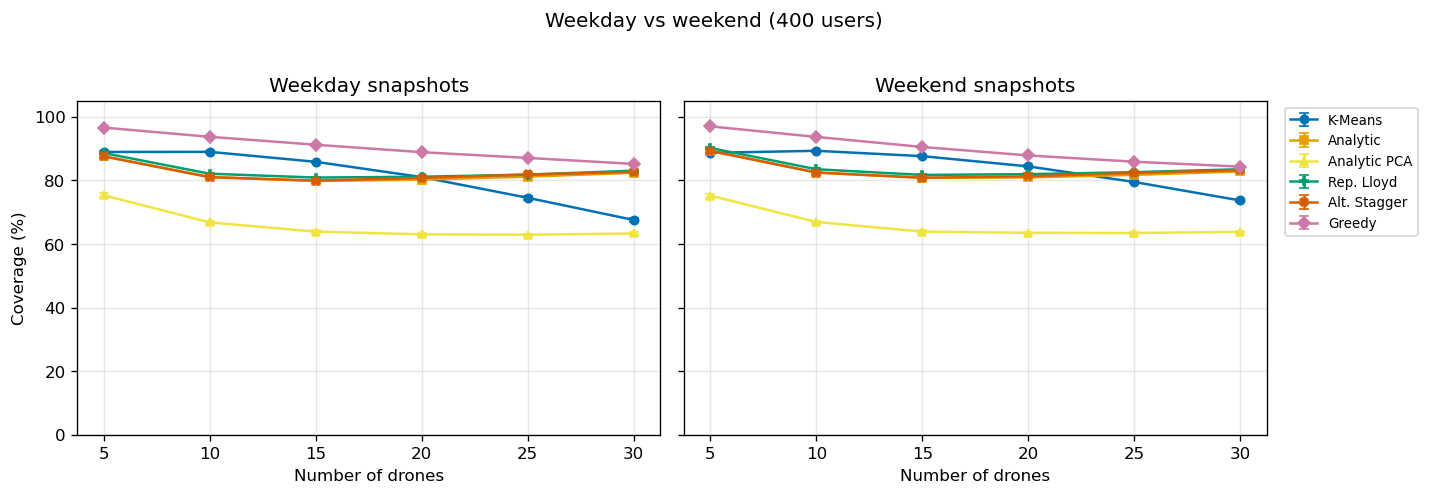

In [26]:
sub = df[df['n_users'] == nu_test]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, dt in zip(axes, ['weekday', 'weekend']):
    d = sub[sub['day_type'] == dt]
    for m in METHODS:
        ms = d[d['method'] == m]
        agg = ms.groupby('n_drones')['coverage_pct'].agg(['mean', 'std', 'count'])
        ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
        ax.errorbar(agg.index, agg['mean'], yerr=ci,
                    label=METHOD_LABELS.get(m, m),
                    color=COLORS.get(m), marker=MARKERS.get(m),
                    markersize=5, capsize=3, linewidth=1.5)
    ax.set_xlabel('Number of drones')
    ax.set_title(f'{dt.capitalize()} snapshots')
    ax.set_ylim(0, 105)

axes[0].set_ylabel('Coverage (%)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle(f'Weekday vs weekend ({int(nu_test)} users)', y=1.02)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'weekday_vs_weekend.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 11. User density scaling

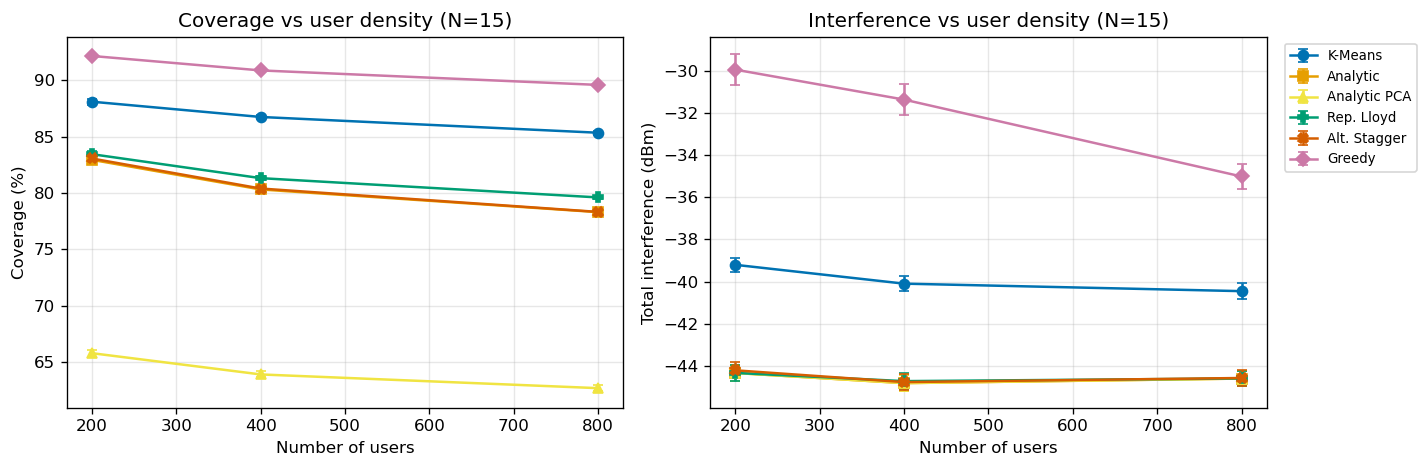

In [27]:
nd_ref = 15
sub = df[df['n_drones'] == nd_ref]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for m in METHODS:
    ms = sub[sub['method'] == m]
    kw = dict(label=METHOD_LABELS.get(m, m), color=COLORS.get(m),
              marker=MARKERS.get(m), markersize=6, linewidth=1.5, capsize=3)
    agg = ms.groupby('n_users')['coverage_pct'].agg(['mean', 'std', 'count'])
    ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
    ax1.errorbar(agg.index, agg['mean'], yerr=ci, **kw)

    agg2 = ms.groupby('n_users')['total_interference_dbm'].agg(['mean', 'std', 'count'])
    ci2 = 1.96 * agg2['std'] / np.sqrt(agg2['count'])
    ax2.errorbar(agg2.index, agg2['mean'], yerr=ci2, **kw)

ax1.set_xlabel('Number of users'); ax1.set_ylabel('Coverage (%)')
ax1.set_title(f'Coverage vs user density (N={nd_ref})')
ax2.set_xlabel('Number of users'); ax2.set_ylabel('Total interference (dBm)')
ax2.set_title(f'Interference vs user density (N={nd_ref})')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'density_scaling.png'),
            bbox_inches='tight', dpi=150)
plt.show()

## 12. Sensitivity analysis

In [28]:
# Load sensitivity CSV files
sens_files = sorted(glob.glob(str(RESULTS_DIR / 'sensitivity' / 'task_*.csv')))
if sens_files:
    df_sens = pd.concat([pd.read_csv(f) for f in sens_files], ignore_index=True)
    print(f'Sensitivity data: {len(df_sens):,} rows from {len(sens_files)} files')
else:
    df_sens = pd.DataFrame()
    print('No sensitivity data found. Run phase=sensitivity on Ibex first.')

Sensitivity data: 4,800 rows from 24 files


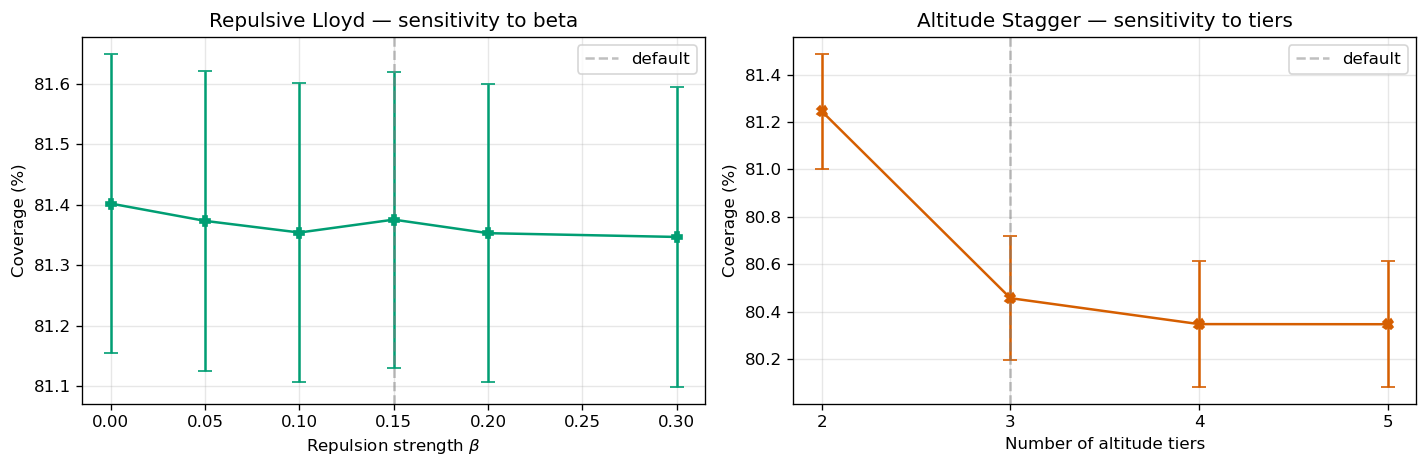

In [29]:
if not df_sens.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Beta sweep for repulsive_lloyd
    d_beta = df_sens[df_sens['param_name'] == 'beta']
    agg = d_beta.groupby('param_value')['coverage_pct'].agg(['mean', 'std', 'count'])
    ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
    ax1.errorbar(agg.index, agg['mean'], yerr=ci,
                 marker='P', color=COLORS['repulsive_lloyd'], capsize=4)
    ax1.set_xlabel(r'Repulsion strength $\beta$')
    ax1.set_ylabel('Coverage (%)')
    ax1.set_title('Repulsive Lloyd — sensitivity to beta')
    ax1.axvline(0.15, color='gray', linestyle='--', alpha=0.5, label='default')
    ax1.legend()

    # n_tiers sweep for altitude_stagger
    d_tier = df_sens[df_sens['param_name'] == 'n_tiers']
    agg = d_tier.groupby('param_value')['coverage_pct'].agg(['mean', 'std', 'count'])
    ci = 1.96 * agg['std'] / np.sqrt(agg['count'])
    ax2.errorbar(agg.index, agg['mean'], yerr=ci,
                 marker='X', color=COLORS['altitude_stagger'], capsize=4)
    ax2.set_xlabel('Number of altitude tiers')
    ax2.set_ylabel('Coverage (%)')
    ax2.set_title('Altitude Stagger — sensitivity to tiers')
    ax2.axvline(3, color='gray', linestyle='--', alpha=0.5, label='default')
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.legend()

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'sensitivity.png'),
                bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('Skipping sensitivity plots (no data).')

## 13. Summary

In [30]:
# Build a compact table: mean (std) per method × metric, for each drone count
# Mark best method in bold
metrics_show = ['coverage_pct', 'throughput_mbps', 'sinr_5th_pct_db',
                'total_interference_dbm']
metric_labels = {
    'coverage_pct': 'Coverage (%)',
    'throughput_mbps': 'Throughput (Mbps)',
    'sinr_5th_pct_db': '5th %ile SINR (dB)',
    'total_interference_dbm': 'Interference (dBm)',
}
# Higher is better for all except interference
higher_better = {'coverage_pct': True, 'throughput_mbps': True,
                 'sinr_5th_pct_db': True, 'total_interference_dbm': False}

sub = df[df['n_users'] == nu_test]
for nd in drone_counts:
    print(f'\n=== N = {nd} drones, {int(nu_test)} users ===')
    rows = []
    for m in METHODS:
        d = sub[(sub['n_drones'] == nd) & (sub['method'] == m)]
        row = {'Method': METHOD_LABELS.get(m, m)}
        for met in metrics_show:
            row[metric_labels[met]] = f"{d[met].mean():.1f} ({d[met].std():.1f})"
        rows.append(row)
    tab = pd.DataFrame(rows).set_index('Method')
    display(tab)


=== N = 5 drones, 400 users ===


,Coverage (%),Throughput (Mbps),5th %ile SINR (dB),Interference (dBm)
Method,,,,
K-Means,88.8 (2.2),26430.1 (1803.9),0.6 (0.6),-56.9 (9.9)
Analytic,88.5 (3.0),20062.5 (2386.1),0.6 (1.2),-57.2 (9.8)
Analytic PCA,75.3 (6.0),15838.7 (2629.8),-6.5 (3.6),-57.2 (9.8)
Rep. Lloyd,89.4 (2.7),20530.5 (2466.9),0.9 (1.2),-57.0 (9.8)
Alt. Stagger,88.5 (3.0),20061.7 (2387.9),0.6 (1.2),-57.2 (9.8)
Greedy,96.8 (1.4),20135.5 (2547.1),5.9 (2.6),-53.6 (9.4)



=== N = 10 drones, 400 users ===


,Coverage (%),Throughput (Mbps),5th %ile SINR (dB),Interference (dBm)
Method,,,,
K-Means,89.2 (2.2),22045.1 (1555.8),1.1 (0.5),-44.5 (6.3)
Analytic,81.8 (3.2),16217.1 (1137.0),-3.7 (2.0),-48.0 (6.4)
Analytic PCA,66.9 (4.5),12654.0 (1265.8),-11.3 (2.4),-48.0 (6.4)
Rep. Lloyd,82.8 (2.9),16493.5 (1052.8),-3.3 (2.0),-47.5 (6.3)
Alt. Stagger,81.8 (3.3),16215.9 (1139.7),-3.7 (2.0),-48.0 (6.4)
Greedy,93.7 (2.0),17044.0 (1909.7),1.7 (2.3),-38.8 (9.5)



=== N = 15 drones, 400 users ===


...

,Coverage (%),Throughput (Mbps),5th %ile SINR (dB),Interference (dBm)
Method,,,,
K-Means,82.7 (4.1),16492.0 (1152.0),0.4 (0.5),-36.1 (4.0)
Analytic,80.6 (2.8),15818.4 (876.3),-6.2 (2.3),-41.1 (4.6)
Analytic PCA,63.3 (3.5),11754.4 (857.8),-14.0 (2.0),-41.1 (4.6)
Rep. Lloyd,81.6 (2.8),16098.1 (912.0),-5.8 (2.3),-41.1 (4.5)
Alt. Stagger,81.1 (2.7),15820.9 (871.2),-5.4 (2.2),-40.7 (4.7)
Greedy,88.4 (2.5),14047.9 (1650.1),-3.2 (3.0),-26.6 (8.9)



=== N = 25 drones, 400 users ===


,Coverage (%),Throughput (Mbps),5th %ile SINR (dB),Interference (dBm)
Method,,,,
K-Means,77.0 (5.9),14743.8 (1035.3),-0.2 (0.6),-33.2 (3.5)
Analytic,81.5 (2.9),16154.1 (934.6),-6.6 (2.5),-37.8 (4.0)
Analytic PCA,63.2 (3.3),11785.1 (854.7),-14.1 (1.9),-37.8 (4.0)
Rep. Lloyd,82.2 (2.8),16394.9 (937.4),-6.4 (2.6),-37.7 (3.8)
Alt. Stagger,82.1 (2.8),16115.1 (943.5),-5.2 (2.4),-37.3 (4.0)
Greedy,86.5 (2.7),13579.2 (1476.5),-4.4 (3.0),-24.3 (8.0)



=== N = 30 drones, 400 users ===


,Coverage (%),Throughput (Mbps),5th %ile SINR (dB),Interference (dBm)
Method,,,,
K-Means,70.6 (6.8),13387.2 (908.5),-0.8 (0.7),-30.9 (3.1)
Analytic,82.6 (2.8),16563.2 (967.7),-6.9 (2.5),-35.1 (3.8)
Analytic PCA,63.6 (3.2),11882.9 (853.5),-14.0 (1.9),-35.1 (3.8)
Rep. Lloyd,83.3 (2.8),16792.2 (991.6),-6.6 (2.6),-35.1 (3.7)
Alt. Stagger,83.0 (2.9),16447.4 (999.6),-5.1 (2.6),-34.8 (3.6)
Greedy,84.8 (3.1),13347.6 (1364.0),-5.4 (2.9),-21.8 (6.6)
